In [19]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [20]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


# CENTRAL AMERICA REGION

In [22]:
SENTINEL_DATA_CSV        = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_EO_SENTINEL.csv"
SENINEL_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_VAL_EO_SENTINEL.csv"

sentinel_df = pd.read_csv(SENTINEL_DATA_CSV)
print(sentinel_df.shape)
sentinel_df.columns

(8774, 32)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE',
       'cloud_threshold_used'],
      dtype='object')

In [17]:
sentinel_df = sentinel_df.drop(columns=['latitude_y', 'longitude_y'])
sentinel_df.columns

Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude_x',
       'longitude_x', 'diameter', 'height', 'species', 'plant_AGB_kg', 'time',
       'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2',
       'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge',
       'CLOUD_COVERAGE'],
      dtype='object')

## DATA PREPROCESSING

In [23]:
null_rows = sentinel_df[sentinel_df.isnull().any(axis=1)]
total_nulls = sentinel_df.isnull().sum().sum()

print(f"Total NULL count           : {total_nulls}")
print(f"Rows with at least one NULL: {len(null_rows)}")
print(f"Total rows                 : {len(sentinel_df)}")
print(f"Percentage                 : {len(null_rows)/len(sentinel_df)*100:.1f}%")

# NULL count per column for only the affected rows
null_col_counts = null_rows.isnull().sum().sort_values(ascending=False)
print("\nNULL count per column in affected rows:")
print(null_col_counts[null_col_counts > 0])

Total NULL count           : 0
Rows with at least one NULL: 0
Total rows                 : 8774
Percentage                 : 0.0%

NULL count per column in affected rows:
Series([], dtype: int64)


In [24]:
#sentinel_df = handle_null_data(sentinel_df)
sentinel_df = sentinel_df.dropna()
print(sentinel_df.shape)
sentinel_df.columns

(8774, 32)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE',
       'cloud_threshold_used'],
      dtype='object')

In [26]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    #'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    #'latitude',            # coordinate
    #'longitude',           # coordinate
]
sentinel_bands = [
    'Blue', 'Green', 'Red'
]
sentinel_indices = [
    'NIR', 'SWIR1', 'SWIR2', 'NDVI',
    'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'
]

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

X = sentinel_df[feature_cols]
y = sentinel_df[target]

### Find correlations

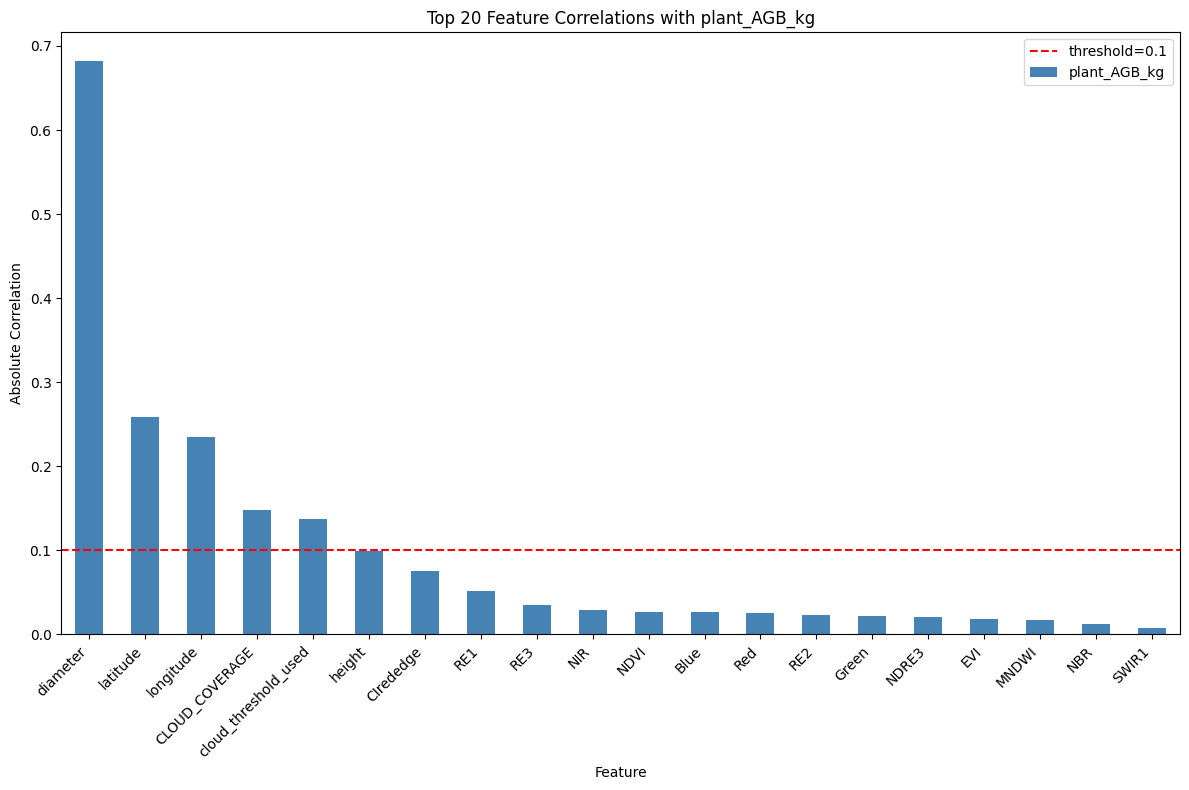

diameter                0.682135
latitude                0.259120
longitude               0.234437
CLOUD_COVERAGE          0.148244
cloud_threshold_used    0.137737
height                  0.099734
CIrededge               0.075032
RE1                     0.051166
RE3                     0.034549
NIR                     0.029325
NDVI                    0.026838
Blue                    0.026532
Red                     0.025423
RE2                     0.023474
Green                   0.021944
NDRE3                   0.020353
EVI                     0.018145
MNDWI                   0.016781
NBR                     0.012546
SWIR1                   0.007646
Name: plant_AGB_kg, dtype: float64


In [27]:
numerical_cols = get_numerical_cols(X)
target_corr = plot_correlation_matrix(X[numerical_cols], y, top_n=20)
print(target_corr)

Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

### Remove Features With Weak Correlation to Target

### Convert categorical variables to one-hot encoding

# LINEAR REGRESSION

In [28]:
%run Model_functions.ipynb

In [ ]:
label_1 = "Sentinel bands only"
results = linear_reg_groups(X_s, y, groups, label_1)

# RANDOM FOREST

In [29]:
sentinel_df['dataset'].unique()

array(['ElSalvador', 'Panama-Chirqui_2', 'CostaRica-Nicoya',
       'CostaRica-Sierpe', 'Belige', 'Panama-Chirqui_1',
       'Honduras-Blanca', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Manguezal', 'Brazil-Maruipe', 'Brazil-AcarauBoca',
       'Brazil-BocaGrande', 'Brazil-Barreto', 'Brazil-Salinas',
       'Brazil-FuroGrande', 'Brazil-Caetano'], dtype=object)

# SEGGREGATE DATA INTO REGIONS

In [30]:
datasets = {}

for dataset_name in sentinel_df['dataset'].unique():
    datasets[dataset_name] = sentinel_df[sentinel_df['dataset'] == dataset_name].drop(columns=['dataset']).copy()
    print(f"{dataset_name:30s} : {len(datasets[dataset_name])} rows")

ElSalvador                     : 2857 rows
Panama-Chirqui_2               : 83 rows
CostaRica-Nicoya               : 313 rows
CostaRica-Sierpe               : 93 rows
Belige                         : 3880 rows
Panama-Chirqui_1               : 70 rows
Honduras-Blanca                : 797 rows
Brazil-Mangue                  : 88 rows
Brazil-Furo_Do_Chato           : 52 rows
Brazil-Manguezal               : 84 rows
Brazil-Maruipe                 : 59 rows
Brazil-AcarauBoca              : 60 rows
Brazil-BocaGrande              : 66 rows
Brazil-Barreto                 : 54 rows
Brazil-Salinas                 : 78 rows
Brazil-FuroGrande              : 52 rows
Brazil-Caetano                 : 88 rows


# COUNTRY LEVEL MODELING

In [81]:
%run Model_functions.ipynb

In [82]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    #'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
]

sentinel_bands = [
    'Blue', 'Green', 'Red'
]
sentinel_indices = [
    'NIR', 'SWIR1', 'SWIR2', 'NDVI',
    'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'
]
useful_categorical = ['plot_id', 'species']

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]
feature_cols

['dataset',
 'plot_id',
 'diameter',
 'height',
 'species',
 'sentinel_time',
 'Blue',
 'Green',
 'Red',
 'RE1',
 'RE2',
 'RE3',
 'NIR',
 'SWIR1',
 'SWIR2',
 'NDVI',
 'MNDWI',
 'NBR',
 'EVI',
 'NDRE1',
 'NDRE2',
 'NDRE3',
 'CIrededge',
 'CLOUD_COVERAGE',
 'cloud_threshold_used']

In [83]:
categorical_cols_orig = get_categorical_cols(sentinel_df)
print("categorical_cols: %s" %categorical_cols_orig)

categorical_cols: ['dataset', 'plot_id', 'start_date', 'end_date', 'species', 'capture_start', 'capture_end', 'sentinel_time']


In [84]:
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
test_cv = 5

In [85]:
def run_experiment(features, target, label):
    for dataset_name in datasets.keys():
        if dataset_name == 'Brazil':
            continue
    
        print(f"\n{dataset_name}")
        data_df = datasets[dataset_name]
    
        label = f"RF: Region: {dataset_name}"
        X = data_df[features]
        y = data_df[target]
    
        groups = X['plot_id'].copy()
        X = X.drop(columns=['plot_id'])
        print(f"X.shape: {X.shape}")
        print(f"y.shape: {y.shape}")
        print(f"Features: {X.columns}")
        print(f"groups: {len(groups.unique())}")
        categorical_cols = get_categorical_cols(X)
        #print("categorical_cols: %s" %categorical_cols)
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)
        #print(f"Features with dummies: {X.columns}")
        
        results = randomForest_groups(X,
                                      y,
                                      test_cv,
                                      groups,
                                      label,
                                      False) #grid
        show_importances(results)

In [86]:
label = f"Region: {dataset_name}. Features: Sentinel bands only"
run_experiment(useful_categorical + sentinel_bands, target, label)


ElSalvador
X.shape: (2857, 4)
y.shape: (2857,)
Features: Index(['species', 'Blue', 'Green', 'Red'], dtype='object')
groups: 144
len(groups.unique()) : 144

 RANDOM FOREST: RF: Region: ElSalvador
Test R²     : -0.0214
Test RMSE   : 294.18 kg
Train R² (log scale): 0.3684
Train R² (orig scale): -0.0080
Train RMSE  : 511.44 kg
Num Features: 13

 Cross-validation ---
CV R² mean: -8.7205
CV R² std : 12.5097
CV scores : [ -3.358  -0.098  -3.066  -3.465 -33.616]

Grouped Cross-validation ---
Grouped CV R² mean: 0.0017
Grouped CV R² std : 0.3394
Grouped CV scores : [ 0.118 -0.313 -0.128  0.352 -0.033  0.571  0.022  0.171 -0.008 -0.737]

Top 4 feature importances:
  Green                                         0.3096  ███████████████
  Blue                                          0.3081  ███████████████
  Red                                           0.2979  ██████████████
  species_racemosa                              0.0295  █

Panama-Chirqui_2
X.shape: (83, 4)
y.shape: (83,)
Features: Ind

In [ ]:
label = f"Region: {dataset_name}. Features: Sentinel bands + Indices"
run_experiment(useful_categorical + sentinel_bands, target, label)


ElSalvador
X.shape: (2857, 4)
y.shape: (2857,)
Features: Index(['species', 'Blue', 'Green', 'Red'], dtype='object')
groups: 144
len(groups.unique()) : 144

 RANDOM FOREST: RF: Region: ElSalvador
Test R²     : -0.0214
Test RMSE   : 294.18 kg
Train R² (log scale): 0.3684
Train R² (orig scale): -0.0080
Train RMSE  : 511.44 kg
Num Features: 13

 Cross-validation ---
CV R² mean: -8.7205
CV R² std : 12.5097
CV scores : [ -3.358  -0.098  -3.066  -3.465 -33.616]


In [ ]:
label = f"Region: {dataset_name}. Features: Height alone"
run_experiment(['height', 'plot_id'], target, label)